https://www.learnpytorch.io/

https://github.com/mrdbourke/pytorch-deep-learning

# PyTorch Computer Vision

<div class="md-typeset__table"><table>
<thead>
<tr>
<th><strong>Topic</strong></th>
<th><strong>Contents</strong></th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>0. Computer vision libraries in PyTorch</strong></td>
<td>PyTorch has a bunch of built-in helpful computer vision libraries, let's check them out.</td>
</tr>
<tr>
<td><strong>1. Load data</strong></td>
<td>To practice computer vision, we'll start with some images of different pieces of clothing from <a href="https://github.com/zalandoresearch/fashion-mnist">FashionMNIST</a>.</td>
</tr>
<tr>
<td><strong>2. Prepare data</strong></td>
<td>We've got some images, let's load them in with a <a href="https://pytorch.org/docs/stable/data.html">PyTorch <code>DataLoader</code></a> so we can use them with our training loop.</td>
</tr>
<tr>
<td><strong>3. Model 0: Building a baseline model</strong></td>
<td>Here we'll create a multi-class classification model to learn patterns in the data, we'll also choose a <strong>loss function</strong>, <strong>optimizer</strong> and build a <strong>training loop</strong>.</td>
</tr>
<tr>
<td><strong>4. Making predictions and evaluating model 0</strong></td>
<td>Let's make some predictions with our baseline model and evaluate them.</td>
</tr>
<tr>
<td><strong>5. Setup device agnostic code for future models</strong></td>
<td>It's best practice to write device-agnostic code, so let's set it up.</td>
</tr>
<tr>
<td><strong>6. Model 1: Adding non-linearity</strong></td>
<td>Experimenting is a large part of machine learning, let's try and improve upon our baseline model by adding non-linear layers.</td>
</tr>
<tr>
<td><strong>7. Model 2: Convolutional Neural Network (CNN)</strong></td>
<td>Time to get computer vision specific and introduce the powerful convolutional neural network architecture.</td>
</tr>
<tr>
<td><strong>8. Comparing our models</strong></td>
<td>We've built three different models, let's compare them.</td>
</tr>
<tr>
<td><strong>9. Evaluating our best model</strong></td>
<td>Let's make some predictions on random images and evaluate our best model.</td>
</tr>
<tr>
<td><strong>10. Making a confusion matrix</strong></td>
<td>A confusion matrix is a great way to evaluate a classification model, let's see how we can make one.</td>
</tr>
<tr>
<td><strong>11. Saving and loading the best performing model</strong></td>
<td>Since we might want to use our model for later, let's save it and make sure it loads back in correctly.</td>
</tr>
</tbody>
</table></div>

<br><br>

<div class="md-typeset__table"><table>
<thead>
<tr>
<th>PyTorch module</th>
<th>What does it do?</th>
</tr>
</thead>
<tbody>
<tr>
<td><a href="https://pytorch.org/vision/stable/index.html"><code>torchvision</code></a></td>
<td>Contains datasets, model architectures and image transformations often used for computer vision problems.</td>
</tr>
<tr>
<td><a href="https://pytorch.org/vision/stable/datasets.html"><code>torchvision.datasets</code></a></td>
<td>Here you'll find many example computer vision datasets for a range of problems from image classification, object detection, image captioning, video classification and more. It also contains <a href="https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets">a series of base classes for making custom datasets</a>.</td>
</tr>
<tr>
<td><a href="https://pytorch.org/vision/stable/models.html"><code>torchvision.models</code></a></td>
<td>This module contains well-performing and commonly used computer vision model architectures implemented in PyTorch, you can use these with your own problems.</td>
</tr>
<tr>
<td><a href="https://pytorch.org/vision/stable/transforms.html"><code>torchvision.transforms</code></a></td>
<td>Often images need to be transformed (turned into numbers/processed/augmented) before being used with a model, common image transformations are found here.</td>
</tr>
<tr>
<td><a href="https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset"><code>torch.utils.data.Dataset</code></a></td>
<td>Base dataset class for PyTorch.</td>
</tr>
<tr>
<td><a href="https://pytorch.org/docs/stable/data.html#module-torch.utils.data"><code>torch.utils.data.DataLoader</code></a></td>
<td>Creates a Python iterable over a dataset (created with <code>torch.utils.data.Dataset</code>).</td>
</tr>
</tbody>
</table></div>

<br><br>

**Overfitting** means our model is learning the training data well but those patterns aren't generalizing to the testing data.

Two of the main ways to fix overfitting include:

* Using a smaller or different model (some models fit certain kinds of data better than others).

* Using a larger dataset (the more data, the more chance a model has to learn generalizable patterns).


https://www.learnpytorch.io/03_pytorch_computer_vision/

## **0. Imports** *

In [ ]:
import time

import torch
from torch import nn
from torch.utils.data import DataLoader

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import seaborn as sns

torch.__version__, torchvision.__version__

('2.6.0+cu124', '0.21.0+cu124')

## **1. Constants** *

In [ ]:
RANDOM_SEED = 42

In [ ]:
!nvidia-smi

Wed Aug 13 21:31:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
if torch.cuda.is_available():
  device = "cuda"
elif torch.mps.is_available():
  device = "mps"
else:
  device = "cpu"

device

'cuda'

## **2. Dataset** *

### 2.0. Download

In [ ]:
%%capture
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

### 2.1. Explore Data

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
train_data.processed_folder

'data/FashionMNIST/processed'

In [ ]:
train_data.raw_folder

'data/FashionMNIST/raw'

In [ ]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
train_data.classes[train_data[0][1]] # each sample's second index is label

'Ankle boot'

In [ ]:
train_data[0][0].shape # [color channel, height, width]

torch.Size([1, 28, 28])

### 2.2. Visualization

In [ ]:
classes_name = train_data.classes

In [ ]:
img, label = train_data[0]
print(f"Image shape: {img.shape}, Image label: {label}")

Image shape: torch.Size([1, 28, 28]), Image label: 9


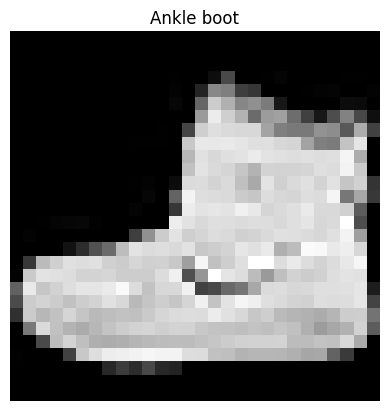

In [ ]:
# plt.imshow(img.squeeze())
plt.imshow(img.reshape(28, 28, 1), cmap="gray")
plt.title(classes_name[label])
plt.axis(False)
plt.show()

Look at images randomly

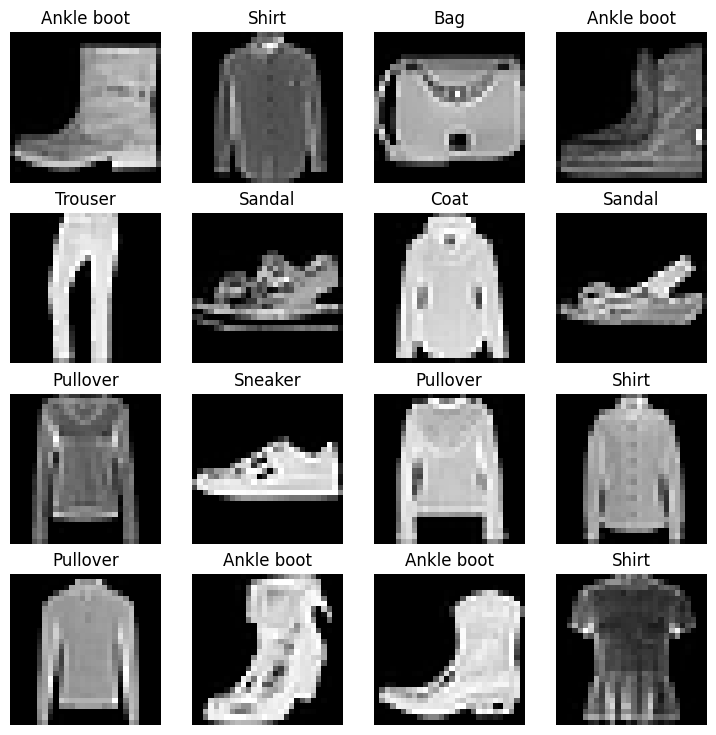

In [ ]:
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

fig, axes = plt.subplots(4, 4, figsize=(9, 9))

for i in range(4):
    for j in range(4):
      random_idx = torch.randint(0, len(train_data), size=[1]).item()
      # random_idx = np.random.randint(0, len(train_data))
      img, label = train_data[random_idx]
      axes[i][j].imshow(img.reshape(28, 28, 1), cmap="gray")
      axes[i][j].set_title(classes_name[label])
      axes[i][j].axis(False)

plt.show()

### 2.3 Prepare DataLoader

Prepare data with a torch.utils.data.DataLoader or DataLoader for short.

The DataLoader helps load data into a model, For training and for inference.

It turns a **large Dataset** into a Python iterable of **smaller chunks**.

These smaller chunks are called batches or mini-batches and can be set by the batch_size parameter.

**Why do this**?

Because it's more computationally efficient.

With mini-batches (small portions of the data), gradient descent is performed more often per epoch (once per mini-batch rather than once per epoch).

**What's a good batch size**?

32 is a good place to start for a fair amount of problems.

Since this is a value you can set (a hyperparameter) you can try all different kinds of values, though generally powers of 2 are used most often

In [ ]:
torch.manual_seed(RANDOM_SEED)

train_dataloader = DataLoader(dataset=train_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=32, shuffle=False, drop_last=True)

In [ ]:
# torch.manual_seed(RANDOM_SEED)

# train_dataloader = DataLoader(dataset=train_data, batch_size=32, shuffle=True, num_workers=2)
# test_dataloader = DataLoader(dataset=test_data, batch_size=32, shuffle=True, num_workers=2)

In [ ]:
train_dataloader.dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
train_dataloader.drop_last, test_dataloader.drop_last

(True, True)

In [ ]:
train_dataloader.num_workers

0

In [ ]:
# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {train_dataloader.batch_size}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {test_dataloader.batch_size}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7b5c943c0c90>, <torch.utils.data.dataloader.DataLoader object at 0x7b5c94515d90>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 312 batches of 32


In [ ]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 9, label size: torch.Size([])


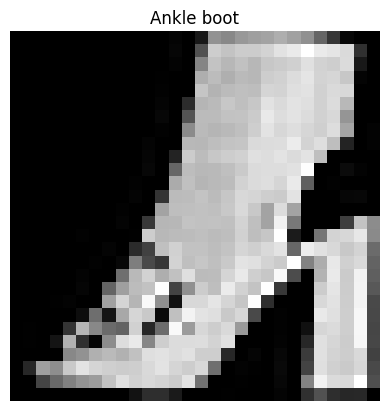

In [ ]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.reshape(28, 28, 1), cmap="gray")
plt.title(classes_name[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

## **3. Model 0**

Linear

### 3.0. Model 0: Build a Baseline Model

In [ ]:
flatten_layer = nn.Flatten()

In [ ]:
sample = train_data[0][0]

sample.shape, flatten_layer(sample).shape

(torch.Size([1, 28, 28]), torch.Size([1, 784]))

In [ ]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self, in_size: int, out_size: int, hidden_units: int):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=in_size, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=out_size)
    )

  def forward(self, x: torch.tensor)-> torch.tensor:
    return self.layer_stack(x)

In [ ]:
# Iterate and move data to device
for data, target in train_dataloader:
    data = data.to(device)
    target = target.to(device)

for data, target in test_dataloader:
    data = data.to(device)
    target = target.to(device)

### 3.1. Model 0: Train the Baseline Model

In [ ]:
torch.manual_seed(RANDOM_SEED)
# torch.cuda.manual_seed(RANDOM_SEED)
# torch.mps.manual_seed(RANDOM_SEED)

fashion_model = FashionMNISTModelV0(in_size=np.prod(train_data[0][0].shape),
                                    out_size=len(train_data.classes),
                                    hidden_units=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=fashion_model.parameters(), lr=0.1)

fashion_model

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
next(fashion_model.parameters()).device

device(type='cuda', index=0)

Since we're computing on batches of data, our loss and evaluation metrics will be calculated per batch rather than across the whole dataset.

In [ ]:
%%time
# Import tqdm for progress bar
# from tqdm.auto import tqdm

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

epochs = 4 + 1
logs = []

# to use this always set drop_last=True in DataLoader
total_samples_train = len(train_dataloader) * train_dataloader.batch_size
total_samples_test =  len(test_dataloader) * test_dataloader.batch_size

# for epoch in tqdm(range(epochs)):
for epoch in range(epochs):
  print(f"epoch: {epoch}\n--------")
  start = time.time()

  ### Train Section
  total_loss_train = 0
  correct_predictions_train = 0
  fashion_model.train()
  for batch_idx, (data, target) in enumerate(train_dataloader):
    # Move data to device
    data, target = data.to(device), target.to(device)

    # Forward pass
    y_logits = fashion_model(data)

    # Count correct predictions (per batch)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    correct_predictions_train += (y_pred == target).sum().item()

    # Calculate loss (per batch)
    loss = loss_fn(y_logits, target)
    total_loss_train += loss.item() # accumulatively add up the loss per epoch

    # Zero Gradient
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Apply Gradient
    optimizer.step()

  ### Test Section
  total_loss_test = 0
  correct_predictions_test = 0
  fashion_model.eval()
  with torch.inference_mode():
    for data, target in test_dataloader:
        data, target = data.to(device), target.to(device)

        y_logits_test = fashion_model(data)
        # Calculate loss (per batch)
        loss = loss_fn(y_logits_test, target)
        total_loss_test += loss.item()

        # Count correct predictions (per batch)
        y_pred_test = torch.softmax(y_logits_test, dim=1).argmax(dim=1)
        correct_predictions_test += (y_pred_test == target).sum().item()

  # Calculate the Metrics and Log Section
  with torch.inference_mode():
    avg_loss_train = total_loss_train / len(train_dataloader)
    avg_loss_test = total_loss_test / len(test_dataloader)

    accu_train = correct_predictions_train / total_samples_train
    accu_test = correct_predictions_test / total_samples_test

    if epoch % 2 == 0:
      logs.append([epoch, avg_loss_train, avg_loss_test])
      print(f"train loss: {avg_loss_train}, train accuracy: {accu_train * 100}")
      print(f"test loss: {avg_loss_test}, test accuracy: {accu_test * 100}")

    print(f"Epoch time: {time.time() - start:.2f}s\n")

epoch: 0
--------
train loss: 0.5903890980045001, train accuracy: 79.17166666666667
test loss: 0.5101829954924492, test accuracy: 82.02123397435898
Epoch time: 10.55s

epoch: 1
--------
Epoch time: 10.08s

epoch: 2
--------
train loss: 0.4550333909114202, train accuracy: 84.05166666666666
test loss: 0.47710955486847806, test accuracy: 83.39342948717949
Epoch time: 10.16s

epoch: 3
--------
Epoch time: 10.24s

epoch: 4
--------
train loss: 0.4358154790441195, train accuracy: 84.7
test loss: 0.46882895905620015, test accuracy: 83.27323717948718
Epoch time: 10.88s

CPU times: user 49.9 s, sys: 319 ms, total: 50.2 s
Wall time: 51.9 s


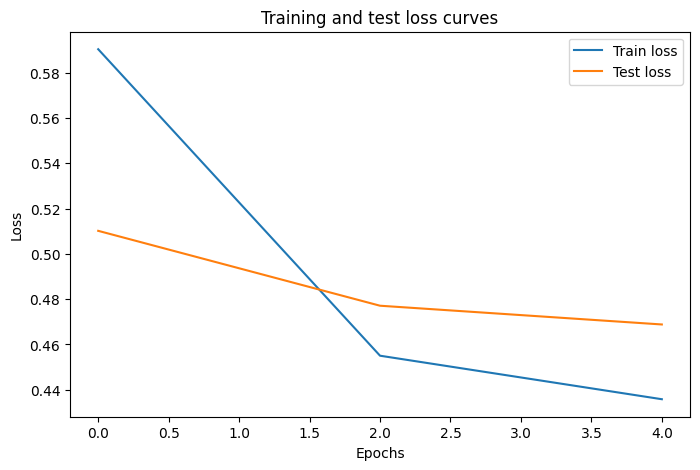

In [ ]:
logs_arr = np.array(logs)

# Plot the loss curves
plt.figure(figsize=(8, 5))
plt.plot(logs_arr[:, 0], logs_arr[:, 1], label="Train loss")
plt.plot(logs_arr[:, 0], logs_arr[:, 2], label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

**CPU**

epoch: 4

train loss: 0.43581548313299817, train accuracy: 84.7

test loss: 0.4688289669366219, test accuracy: 83.27323717948718

Epoch time: 12.82s

CPU times: user 1min 3s, sys: 73.3 ms, total: 1min 3s

Wall time: 1min 4s


**GPU**

epoch: 4

train loss: 0.4358154790441195, train accuracy: 84.7

test loss: 0.46882895905620015, test accuracy: 83.27323717948718

Epoch time: 10.03s

CPU times: user 48.6 s, sys: 359 ms, total: 48.9 s

Wall time: 50.9 s

## **4. Function to Evaluate Models**

In [ ]:
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               device="cpu"):
    model.to(device)
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.inference_mode():
        for X, y in data_loader:
            # Set device
            X, y = X.to(device), y.to(device)

            y_logits = model(X)
            batch_loss = loss_fn(y_logits, y).item()

            total_loss += (batch_loss * y.size(0))  # sum loss over samples
            y_pred = y_logits.argmax(dim=1)       # logits → labels
            correct_predictions += (y_pred == y).sum().item()
            total_samples += y.size(0)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": total_loss / total_samples,
        "model_acc": correct_predictions / total_samples
    }


In [ ]:
# torch.manual_seed(RANDOM_SEED)
# torch.cuda.manual_seed(RANDOM_SEED)
# torch.mps.manual_seed(RANDOM_SEED)

# # Calculate fashion_model results on test dataset
# model_0_results = eval_model(model=fashion_model,
#                              data_loader=test_dataloader,
#                              loss_fn=loss_fn)
# model_0_results

## **5. Model 1**

Building a Better Model with non-linearity

In [ ]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self, in_size: int, out_size: int, hidden_units: int):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(), # flatten inputs into single vector
        nn.Linear(in_features=in_size, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=out_size),
    )

  def forward(self, x: torch.tensor)-> torch.tensor:
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(RANDOM_SEED)
# torch.cuda.manual_seed(RANDOM_SEED)
# torch.mps.manual_seed(RANDOM_SEED)

fashion_model_1 = FashionMNISTModelV1(in_size=np.prod(train_data[0][0].shape),
                                    out_size=len(train_data.classes),
                                    hidden_units=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=fashion_model_1.parameters(), lr=0.1)

fashion_model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
next(fashion_model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
%%time
# Import tqdm for progress bar
from tqdm.auto import tqdm

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

epochs= 4 + 1
logs = []

# for epoch in tqdm(range(epochs)):
for epoch in range(epochs):
  torch.manual_seed(RANDOM_SEED)
  torch.cuda.manual_seed(RANDOM_SEED)
  torch.mps.manual_seed(RANDOM_SEED)

  print(f"epoch: {epoch}\n--------")
  start = time.time()

  ### Training
  total_loss_train = 0.0
  total_samples_train = 0
  correct_predictions_train = 0

  fashion_model_1.train()
  for batch, (data, traget) in enumerate(train_dataloader):
      # Set device
      data, target = data.to(device), traget.to(device)

      # Forward pass
      y_logits = fashion_model_1(data)

      # Calculate the loss per batch
      loss = loss_fn(y_logits, target)
      total_loss_train += (loss.item() * target.size(0)) # sum loss over samples

      # Count correct predictions
      correct_predictions_train += (torch.argmax(y_logits, dim=1) == target).sum().item()
      total_samples_train += target.size()[0]

      # Zero Grad
      optimizer.zero_grad()

      # Backpropagation
      loss.backward()

      # Apply Grad
      optimizer.step()

  ### Testing
  fashion_model_1.eval()
  with torch.inference_mode():
      test_result = eval_model(fashion_model_1, test_dataloader, loss_fn, device)

      # Calculate the Metrics and Log Section
      avg_loss_train = total_loss_train / total_samples_train
      accu_train = correct_predictions_train / total_samples_train

      if epoch % 2 == 0:
        logs.append([epoch, avg_loss_train, test_result['model_loss']])
        print(f"train loss: {avg_loss_train}, train accuracy: {accu_train * 100}")
        print(f"test loss: {test_result['model_loss']}, test accuracy: {test_result['model_acc'] * 100}")

      print(f"Epoch time: {time.time() - start:.2f}s\n")

epoch: 0
--------
train loss: 0.6460702259898186, train accuracy: 77.17
test loss: 0.5392293051744883, test accuracy: 80.71915064102564
Epoch time: 10.27s

epoch: 1
--------
Epoch time: 9.61s

epoch: 2
--------
train loss: 0.4464782964448134, train accuracy: 84.14666666666668
test loss: 0.4866091470257976, test accuracy: 82.75240384615384
Epoch time: 10.17s

epoch: 3
--------
Epoch time: 10.13s

epoch: 4
--------
train loss: 0.4138521370013555, train accuracy: 85.34833333333334
test loss: 0.4422773187024853, test accuracy: 84.40504807692307
Epoch time: 10.05s

CPU times: user 49.3 s, sys: 288 ms, total: 49.6 s
Wall time: 50.2 s


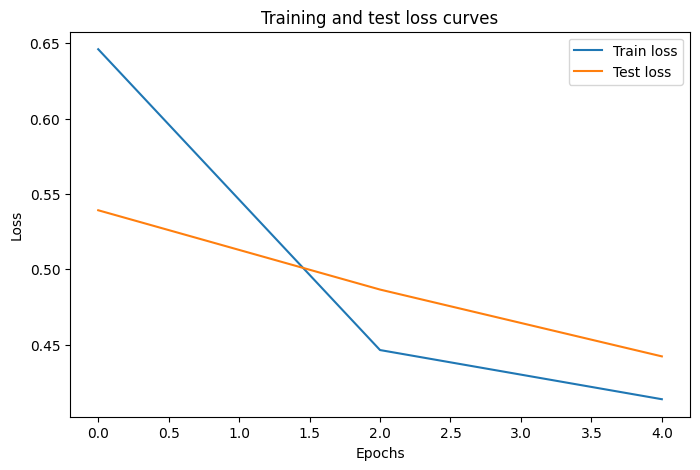

In [ ]:
logs_arr = np.array(logs)

# Plot the loss curves
plt.figure(figsize=(8, 5))
plt.plot(logs_arr[:, 0], logs_arr[:, 1], label="Train loss")
plt.plot(logs_arr[:, 0], logs_arr[:, 2], label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

## **6. Train Test Functions** *

### 6.0. Functions

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device = "cpu",
               random_seed: int = None):
    # Set random seed
    if random_seed is not None:
      torch.manual_seed(random_seed)
      torch.cuda.manual_seed(random_seed)
      torch.mps.manual_seed(random_seed)

    # Send model to device
    model.to(device)
    model.train()

    total_loss = 0.0
    total_samples = 0
    correct_predictions = 0

    for batch, (data, target) in enumerate(data_loader):
        data, target = data.to(device), target.to(device)

        # Forward pass
        y_logits = model(data)

        # Loss
        loss = loss_fn(y_logits, target)
        total_loss += (loss.item() * target.size(0))

        # Accuracy
        correct_predictions += (torch.argmax(y_logits, dim=1) == target).sum().item()
        total_samples += target.size(0)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = total_loss / total_samples
    train_acc = (correct_predictions / total_samples) * 100

    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

In [ ]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device = "cpu"
              ):
    # Send model to device
    model.to(device)
    model.eval()

    total_loss = 0.0
    total_samples = 0
    correct_predictions = 0

    with torch.inference_mode():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)

            y_logits = model(data)
            batch_loss = loss_fn(y_logits, target).item()
            total_loss += batch_loss * target.size(0)  # sum loss over samples

            y_pred = y_logits.argmax(dim=1)  # logits → labels
            correct_predictions += (y_pred == target).sum().item()
            total_samples += target.size(0)

    test_loss = total_loss / total_samples
    test_acc = (correct_predictions / total_samples) * 100

    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%")

### 6.1. Testing Train and Test Functions

In [ ]:
# torch.manual_seed(RANDOM_SEED)

# fashion_model_2 = FashionMNISTModelV1(in_size=np.prod(train_data[0][0].shape),
#                                     out_size=len(train_data.classes),
#                                     hidden_units=10).to(device)

# loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(params=fashion_model_2.parameters(), lr=0.1)

In [ ]:
# next(fashion_model_2.parameters()).device

In [ ]:
# %%time
# from tqdm.auto import tqdm

# torch.manual_seed(RANDOM_SEED)
# torch.cuda.manual_seed(RANDOM_SEED)
# torch.mps.manual_seed(RANDOM_SEED)

# epochs= 4 + 1

# for epoch in tqdm(range(epochs)):
#   print(f"epoch: {epoch}\n--------")
#   start = time.time()

#   ### Training
#   train_step(fashion_model_2, train_dataloader, loss_fn, optimizer, device, RANDOM_SEED)

#   ### Testing
#   test_step(fashion_model_2, test_dataloader, loss_fn, device)
#   print(f"Epoch time: {time.time() - start:.2f}s\n")


"""
100%
 5/5 [00:50<00:00, 10.17s/it]

epoch: 0
--------
Train loss: 0.64607 | Train accuracy: 77.17%
Test loss: 0.53923 | Test accuracy: 80.72%
Epoch time: 9.61s

epoch: 1
--------
Train loss: 0.48152 | Train accuracy: 82.86%
Test loss: 0.50651 | Test accuracy: 81.88%
Epoch time: 9.97s

epoch: 2
--------
Train loss: 0.44648 | Train accuracy: 84.15%
Test loss: 0.48661 | Test accuracy: 82.75%
Epoch time: 9.98s

epoch: 3
--------
Train loss: 0.42672 | Train accuracy: 84.95%
Test loss: 0.46626 | Test accuracy: 83.57%
Epoch time: 10.42s

epoch: 4
--------
Train loss: 0.41385 | Train accuracy: 85.35%
Test loss: 0.44228 | Test accuracy: 84.41%
Epoch time: 10.28s

CPU times: user 48.8 s, sys: 331 ms, total: 49.2 s
Wall time: 50.3 s
"""

'\n100%\n\u20075/5\u2007[00:50<00:00,\u200710.17s/it]\n\nepoch: 0\n--------\nTrain loss: 0.64607 | Train accuracy: 77.17%\nTest loss: 0.53923 | Test accuracy: 80.72%\nEpoch time: 9.61s\n\nepoch: 1\n--------\nTrain loss: 0.48152 | Train accuracy: 82.86%\nTest loss: 0.50651 | Test accuracy: 81.88%\nEpoch time: 9.97s\n\nepoch: 2\n--------\nTrain loss: 0.44648 | Train accuracy: 84.15%\nTest loss: 0.48661 | Test accuracy: 82.75%\nEpoch time: 9.98s\n\nepoch: 3\n--------\nTrain loss: 0.42672 | Train accuracy: 84.95%\nTest loss: 0.46626 | Test accuracy: 83.57%\nEpoch time: 10.42s\n\nepoch: 4\n--------\nTrain loss: 0.41385 | Train accuracy: 85.35%\nTest loss: 0.44228 | Test accuracy: 84.41%\nEpoch time: 10.28s\n\nCPU times: user 48.8 s, sys: 331 ms, total: 49.2 s\nWall time: 50.3 s\n'



  >**Note**: The training time on CUDA vs CPU will depend largely on the quality of the CPU/GPU you're using. Read on for a more explained answer.

  >**Question**: "I used a GPU but my model didn't train faster, why might that be?"

  >Answer: Well, one reason could be because your dataset and model are both so small (like the dataset and model we're working with) the benefits of using a GPU are outweighed by the time it actually takes to transfer the data there.

  >There's a small bottleneck between copying data from the CPU memory (default) to the GPU memory.

  >So for smaller models and datasets, the CPU might actually be the optimal place to compute on.

  >But for larger datasets and models, the speed of computing the GPU can offer usually far outweighs the cost of getting the data there.

  >However, this is largely dependent on the hardware you're using. With practice, you will get used to where the best place to train your models is.


## **7. Model 2**

Building a **Convolutional Neural Network** (CNN)

CNN's are known for their capabilities to find patterns in visual data.

It follows the typical structure of a convolutional neural network:

`Input layer -> [Convolutional layer -> activation layer -> pooling layer] -> Output layer`

>**Question**: What should we set the parameters of our nn.Conv2d() layers?
>
>That's a good one. But similar to many other things in machine learning, the values of these aren't set in stone (and recall, because these values are ones we can set ourselves, they're referred to as "hyperparameters").
>
>The best way to find out is to try out different values and see how they effect your model's performance.
>
>Or even better, find a working example on a problem similar to yours (like we've done with TinyVGG) and copy it.

### 7.0. Build a CNN Model

In [ ]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self,
               input_shape: int,
               output_shape: int,
               hidden_units: int
               ):

    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    super().__init__()

    self.input_shape = input_shape
    self.output_shape = output_shape
    self.hidden_units = hidden_units

    self.conv_block_0 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),

        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),

        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) # default stride value is same as kernel_size
    )

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        # Where did this in_features shape come from?
        # Print the shape of previous block to get the shape :)
        # It's because each layer of our network compresses and changes the shape of our input data.
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self, x: torch.tensor)-> torch.tensor:
      x = self.conv_block_0(x)
      # print(x.shape) # -> torch.Size([32, 10, 14, 14])
      x = self.conv_block_1(x)
      # print(x.shape) # -> torch.Size([32, 10, 7, 7])
      x = self.classifier(x)
      # print(x.shape)
      return x

Find the input of Linear layer with dummy data

In [ ]:
random_img = torch.randn(1, 28, 28)
random_img.shape

torch.Size([1, 28, 28])

In [ ]:
temp_model = FashionMNISTModelV2(1, 10, 10)
temp_model(random_img.unsqueeze(0))

# torch.Size([1, 10, 14, 14])
# torch.Size([1, 10, 7, 7]) This is the input of Linear layer that going to be Flatten

tensor([[-0.0291,  0.0058, -0.0322,  0.0060, -0.0169, -0.0903, -0.0077, -0.0452,
          0.0049,  0.0295]], grad_fn=<AddmmBackward0>)

### 7.1. Stepping through **nn.Conv2d()**

>**Question**: What does the "2d" in nn.Conv2d() stand for?
>
>The 2d is for 2-dimensional data. As in, our images have two dimensions: height and width. Yes, there's color channel dimension but each of the color channel dimensions have two dimensions too: height and width.
>
>For other dimensional data (such as 1D for text or 3D for 3D objects) there's also nn.Conv1d() and nn.Conv3d().


In [ ]:
torch.manual_seed(RANDOM_SEED)

# batch of images
input_imgs = torch.randn(32, 3, 64, 64)
test_img = input_imgs[0]

test_img.shape

torch.Size([3, 64, 64])

* in_channels (int) - Number of channels in the input image.
* out_channels (int) - Number of channels produced by the convolution.
* kernel_size (int or tuple) - Size of the convolving kernel/filter.
* stride (int or tuple, optional) - How big of a step the convolving kernel * * takes at a time. Default: 1.
* padding (int, tuple, str) - Padding added to all four sides of input. Default: 0

In [ ]:
conv_2d = nn.Conv2d(in_channels=3,
                    out_channels=10,
                    kernel_size=3,
                    stride=1,
                    padding=0)

In [ ]:
# conv_2d(test_img.unsqueeze(0)).shape
conv_2d(test_img).shape

torch.Size([10, 62, 62])

### 7.2. Stepping through **nn.MaxPool2d()**

In [ ]:
# Print out original image shape without and with unsqueezed dimension
print(f"Test image original shape: {test_img.shape}")

# Create a sample nn.MaxPoo2d() layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through just the conv_layer
test_image_through_conv = conv_2d(test_img)
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Shape after going through conv_layer(): torch.Size([10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([10, 31, 31])


In [ ]:
torch.manual_seed(42)
# Create a random tensor with a similar number of dimensions to our images
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"Random tensor:\n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2) # see what happens when you change the kernel_size value

# Pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor:\n{max_pool_tensor} <- this is the maximum value from random_tensor")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")

Random tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])

Max pool tensor:
tensor([[[[0.3367]]]]) <- this is the maximum value from random_tensor
Max pool tensor shape: torch.Size([1, 1, 1, 1])


### 7.3. Train Model

In [ ]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

fashion_model_3 = FashionMNISTModelV2(input_shape=1, # Num of Channels
                                      output_shape=len(train_data.classes),
                                      hidden_units=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=fashion_model_3.parameters(), lr=0.1)

In [ ]:
fashion_model_3

FashionMNISTModelV2(
  (conv_block_0): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_1): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
%%time
from tqdm.auto import tqdm

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

epochs= 4 + 1

# for epoch in tqdm(range(epochs)):
for epoch in range(epochs):
  print(f"epoch: {epoch}\n--------")
  start = time.time()

  ### Training
  train_step(fashion_model_3, train_dataloader, loss_fn, optimizer, device, RANDOM_SEED)

  ### Testing
  test_step(fashion_model_3, test_dataloader, loss_fn, device)

  print(f"Epoch time: {time.time() - start:.2f}s\n")

epoch: 0
--------
Train loss: 0.59807 | Train accuracy: 78.38%
Test loss: 0.38767 | Test accuracy: 86.44%
Epoch time: 12.97s

epoch: 1
--------
Train loss: 0.35513 | Train accuracy: 87.11%
Test loss: 0.34075 | Test accuracy: 87.69%
Epoch time: 12.28s

epoch: 2
--------
Train loss: 0.31831 | Train accuracy: 88.49%
Test loss: 0.32495 | Test accuracy: 88.05%
Epoch time: 12.35s

epoch: 3
--------
Train loss: 0.29815 | Train accuracy: 89.15%
Test loss: 0.31757 | Test accuracy: 88.21%
Epoch time: 12.46s

epoch: 4
--------
Train loss: 0.28507 | Train accuracy: 89.73%
Test loss: 0.30597 | Test accuracy: 88.61%
Epoch time: 12.39s

CPU times: user 1min, sys: 392 ms, total: 1min 1s
Wall time: 1min 2s


## **8. Models Reports**

**Cuda**
- **Model 0** Linear:
  - epoch: 4

    train loss: 0.43582, train accuracy: 84.70%

    test loss: 0.46883, test accuracy: 83.27%

    total: 51.1 s

- **Model 1** Non-Linear:
  - epoch: 4

    train loss: 0.41385, train accuracy: 85.35%

    test loss: 0.44228, test accuracy: 84.41%

    total: 49.2 s

- **Model 2** CNN:
  - epoch: 4

    Train loss: 0.29001 | Train accuracy: 89.44%

    Test loss: 0.31402 | Test accuracy: 88.55%

    total: 1min

## **9. Save and Load**

### 9.0. Save CNN Model

In [ ]:
cnn_model_dict = {
    "model_state_dict": fashion_model_3.to("cpu").state_dict(), # Can't deserialize cuda with cpu on loading
    "input_size": fashion_model_3.input_shape,
    "output_size": fashion_model_3.output_shape,
    "hidden_units": fashion_model_3.hidden_units,
    "batch_size": train_dataloader.batch_size,
    "img_shape": next(iter(train_dataloader))[0][0].shape,
}

fashion_model_3 = fashion_model_3.to(device) # Put back model to current device

In [ ]:
torch.save(cnn_model_dict, "cnn_model.pth")

### 9.1. Load CNN Model

You can find the model here -
https://github.com/RezaTaheri01/my-ml-journey/blob/main/Codes/pytorch/models/pytorch_0003/cnn_model.pth

In [ ]:
cnn_model_dict_l = torch.load("cnn_model.pth")
cnn_model_dict_l.keys()

dict_keys(['model_state_dict', 'input_size', 'output_size', 'hidden_units', 'batch_size', 'img_shape'])

In [ ]:
fashion_model_4 = FashionMNISTModelV2(cnn_model_dict_l["input_size"],
                                      cnn_model_dict_l["output_size"],
                                      cnn_model_dict_l["hidden_units"])

In [ ]:
fashion_model_4.load_state_dict(cnn_model_dict_l["model_state_dict"])

<All keys matched successfully>

In [ ]:
fashion_model_4 = fashion_model_4.to(device)

In [ ]:
next(fashion_model_4.parameters()).device

device(type='cuda', index=0)

## **10. Make and evaluate random predictions with best model**

Create a function make_predictions() where we can pass the model and some data for it to predict on

In [ ]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = "cpu"):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

Choose some samples from test data

In [ ]:
import random

random.seed(RANDOM_SEED)
NUM_SAMPLES = 12

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=NUM_SAMPLES):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({classes_name[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


Use make_predictions to predict on test_samples

In [ ]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=fashion_model_4,
                             data=test_samples,
                             device=device)

# View first two prediction probabilities list
pred_probs[:2]

tensor([[8.2950e-08, 6.2367e-08, 9.5786e-08, 3.6530e-09, 1.1597e-08, 9.9888e-01,
         1.7188e-08, 9.2058e-06, 1.6694e-05, 1.0960e-03],
        [1.7381e-03, 9.6865e-01, 9.6346e-04, 2.9218e-03, 2.2965e-02, 4.6309e-05,
         2.4917e-03, 1.1717e-05, 6.8790e-06, 2.0170e-04]])

Use argmax to get labels

In [ ]:
# Turn the prediction probabilities into prediction labels by taking the argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 6, 4, 7, 1, 9, 7, 2])

In [ ]:
# Are our predictions in the same form as our test labels?
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1, 9, 7, 2],
 tensor([5, 1, 7, 4, 3, 6, 4, 7, 1, 9, 7, 2]))

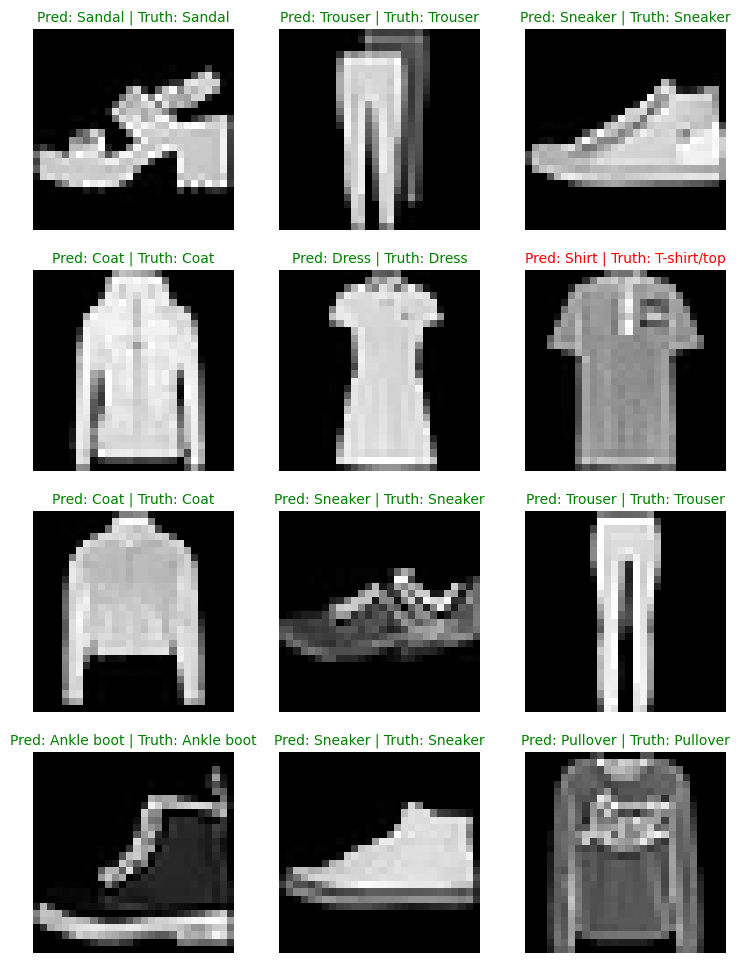

In [ ]:
# Plot predictions
ncols = 3
nrows = (NUM_SAMPLES // ncols) + 1 if NUM_SAMPLES % 3 != 0 else NUM_SAMPLES // ncols

plt.figure(figsize=(9, 3 * nrows))

for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = classes_name[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = classes_name[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

## **11. Making a confusion matrix for further prediction evaluation**

in most cases it’s perfectly fine to use **sklearn.metrics** instead of **torchmetrics**, but there are trade-offs.

* Quick post-training check? → sklearn.metrics is fine.

* Training loop + GPU tensors + distributed setup? → torchmetrics is better.

In [ ]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
y_trues = []
fashion_model_4.eval()
with torch.inference_mode():
  # for X, y in tqdm(test_dataloader, desc="Making predictions"):
  for X, y in test_dataloader:
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = fashion_model_4(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
    y_trues.append(y.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)
y_true_tensor = torch.cat(y_trues)

In [ ]:
y_pred_tensor.shape, y_true_tensor.shape

(torch.Size([9984]), torch.Size([9984]))

### 11.0. classification_report

In [ ]:
print(classification_report(y_true_tensor.numpy(), y_pred_tensor.numpy()))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83      1000
           1       0.97      0.98      0.98       997
           2       0.82      0.80      0.81       999
           3       0.90      0.86      0.88       999
           4       0.77      0.86      0.81       999
           5       0.98      0.97      0.98       997
           6       0.74      0.61      0.67       999
           7       0.96      0.95      0.96       999
           8       0.96      0.97      0.97       997
           9       0.96      0.97      0.96       998

    accuracy                           0.89      9984
   macro avg       0.89      0.89      0.88      9984
weighted avg       0.89      0.89      0.88      9984



In [ ]:
classes_name[6], classes_name[4], classes_name[2] # f1: 0.67, 0.81, 0.81

('Shirt', 'Coat', 'Pullover')

### 11.1. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true_tensor.numpy(), y_pred_tensor.numpy())

In [ ]:
# plt.figure(figsize=(8, 5))
# sns.heatmap(data=cm, annot=True, cmap="Blues", fmt=".0f")

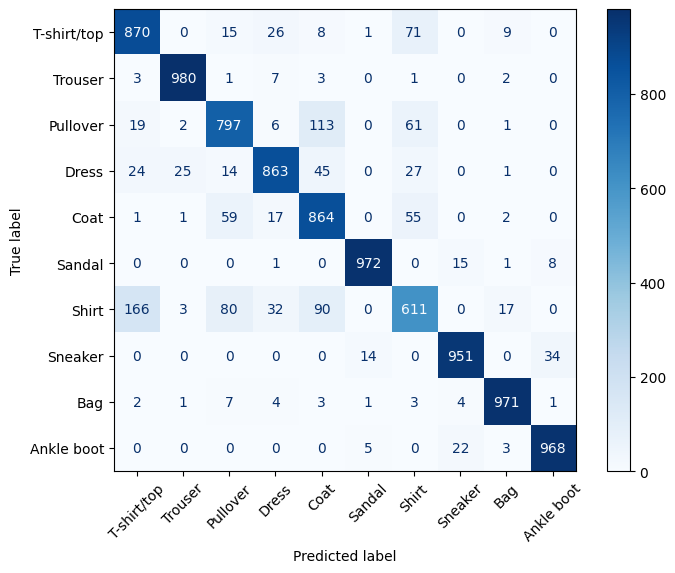

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_name)
fig, ax = plt.subplots(figsize=(8, 6))  # Optional: control figure size
disp.plot(cmap="Blues", ax=ax)
ax.set_xticklabels(classes_name, rotation=45)  # Rotate labels
plt.show()

In [ ]:
print(classes_name)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Class 6 summary

**Recall**

166 samples of class 6(Shirt) categories as class 0(T-shirt/top)

80 samples of class 6(Shirt) categories as class 2(Pullover)

90 samples of class 6(Shirt) categories as class 4(Coat)

**Precision**

71 samples of class 0(T-shirt/top) categories as class 6(shirt)

61 samples of class 2(Pullover) categories as class 6(shirt)

55 samples of class 4(Coat) categories as class 6(shirt)







### 11.2 Confusion Matrix with torchmetrics

In [ ]:
# # See if torchmetrics exists, if not, install it
# try:
#     import torchmetrics, mlxtend
#     print(f"mlxtend version: {mlxtend.__version__}")
#     assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
# except:
#     !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
#     import torchmetrics, mlxtend
#     print(f"mlxtend version: {mlxtend.__version__}")

In [ ]:
# from torchmetrics import ConfusionMatrix
# from mlxtend.plotting import plot_confusion_matrix

# # 2. Setup confusion matrix instance and compare predictions to targets
# confmat = ConfusionMatrix(num_classes=len(classes_name), task='multiclass')
# confmat_tensor = confmat(preds=y_pred_tensor,
#                          target=y_true_tensor)

# # 3. Plot the confusion matrix
# fig, ax = plot_confusion_matrix(
#     conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy
#     class_names=classes_name, # turn the row and column labels into class names
#     figsize=(10, 7)
# );